In [1]:
import pandas as pd
import os
os.chdir('D://My_projects//Drug Use//Final Thesis//alcohol')

In [32]:
import os
os.chdir("D://My_projects//Drug Use//ICPSR_21600-V25//ICPSR_21600//DS0001")

In [33]:
file_path="21600-0001-Data.tsv"

In [34]:
df1 = pd.read_csv(file_path, sep='\t', low_memory=False)

In [39]:
df_all['NeighborhoodType_6'].unique()

array([False,  True])

In [2]:
df_all_filtered=pd.read_csv('W1-4_fulldata_filtered.csv')

In [94]:
index_vars = [c for c in df_all.columns if "index" in c.lower()]
index_vars


['GPA_Index',
 'SchoolTrouble_Index',
 'DisciplinaryIndex',
 'ParentalWarmth_Index',
 'ParentalSupervision_Index',
 'Delinquency_Index',
 'SportsParticipation_Index',
 'SubstanceUse_Index',
 'MentalDistress_Index',
 'SES_Index',
 'SexAttitudes_Index',
 'SchoolTrouble_Index_Z',
 'SchoolBehavior_Index',
 'TobaccoUse_Index',
 'AlcoholUse_Index',
 'PeerSubstance_Index',
 'NeighborhoodCohesion_Index',
 'ParentalSupport_Index',
 'Support_Index',
 'LowReligiosityIndex_W1']

In [95]:
index_vars = [c for c in cols if "index" in c.lower()]
index_vars


['Delinquency_Index',
 'GPA_Index',
 'ParentalWarmth_Index',
 'ParentalSupervision_Index']

In [112]:
cols_to_drop = [c for c in df_all_filtered.columns if ("STUD" in c) or ("TWIN" in c ) or ("AH" in c) ]

print(f"Dropping {len(cols_to_drop)} columns:")
print(cols_to_drop)

df_all_filtered = df_all_filtered.drop(columns=cols_to_drop)
for v in df_all_filtered:
    print(v)

Dropping 16 columns:
['STUDSIBA', 'TWINA', 'STUDSIBB', 'TWINB', 'STUDSIBC', 'TWINC', 'STUDSIBD', 'TWIND', 'STUDSIBE', 'TWINE', 'STUDSIBF', 'TWINF', 'STUDSIBG', 'TWING', 'AH_PVT', 'AH_RAW']
Age when Moved to Current Residence
Race
SleepTrouble_W1
Moodiness_W1
Fearfulness_W1
WeightPerception_W1
LiftWeights_W1
Hours of Sleep
NightAway_W1
SchoolTaught_Smoking_W1
SchoolTaught_Drinking_W1
TimesSkippedSchool
SchoolSuspension
SchoolExpulsion
Trouble_GetAlong_Teachers_W1
Trouble Paying Attention
Trouble_HomeworkCompletion_W1
TroubleGetAlong_Students_W1
SchoolCloseness
Counseling_W1
SelfRatedIntelligence_W1
TroubleConcentrating_W1
FeelingDepressed_W1
TooTiredToDoThings_W1
BirthOrder_W1
MotherEverSmoked_W1
ClosenessToMother_W1
FatherEverSmoked_W1
ClosenessToFather_W1
Mother_Education
Father_Education
ClosenessToMotherAlt_W1
MotherCares_W1
ClosenessToFatherAlt_W1
FatherCares_W1
FriendsRespect_Sex
Rev_FeelGuilty_Sex
Rev_UpsetMother_Sex
Pleasure_Sex
Relax_Sex
Attractive_Sex
LessLonely_Sex
ProudOfYou

In [7]:
len(df_all_filtered.columns)

210

In [6]:
df_all_filtered = df_all_filtered.drop(columns=["DaysMarijuanaPast12M_W4"], errors="ignore")


In [14]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "TotalDrinking"  
corr_thr = 0.09                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df_all_filtered.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df_filtered = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 50 vars with |corr| ≥ 0.090
[Step 2] Dropped 19 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 31

=== FINAL FEATURE SET ===
Variables kept (n=31):
Sex_Female
Age at First Drink
SexAttitudes_Index
SchoolSuspension_Z
Delinquency_Index
SchoolBehavior_Index
SchoolTrouble_Index
Age_FirstMarijuana
PeerSubstance_Index
InjuredSomeone
LessLonely_Sex
FriendsRespect_Sex
GPA_Index
Rev_FeelGuilty_Sex
Relax_Sex_Z
SoldDrugs_Z
WantCollege_W1
EverTried_Cigarette_Z
Trouble Paying Attention
PhysicalFight_W1
Attractive_Sex
ExpectCollege_W1
LowReligiosityIndex_W1
Fight_Serious_Z
Trouble_GetAlong_Teachers_W1
Pleasure_Sex
FriendCare_W1
WeaponThreat_W1
DrinkFrequency_Past12mo
HighEduExpectations
Jumped_W1


In [5]:
df_all["InterviewerUnsafe"].unique()

array([ 0.,  1., nan])

In [211]:
df_all["SleepTrouble_W1"].unique()

array([ 0.,  2.,  1.,  3.,  4., nan])

In [183]:
df_all.shape

(5114, 2961)

In [193]:
df_all.columns

Index(['AID', 'BirthYear', 'Age when Moved to Current Residence', 'Race',
       'SleepTrouble_W1', 'Moodiness_W1', 'Fearfulness_W1',
       'WeightPerception_W1', 'LiftWeights_W1', 'Hours of Sleep',
       ...
       'ReligionGroup_Muslim', 'ReligionGroup_Other',
       'ReligionGroup_Protestant', 'ReligionGroup_nan', 'BuildingType_2',
       'BuildingType_3', 'BuildingType_4', 'BuildingType_5', 'BuildingType_7',
       'BuildingType_<NA>'],
      dtype='object', length=255)

In [16]:
df["HighEduExpectations"] =df_all['HighEduExpectations']

In [19]:
df['Sex_Female']=df_all['Sex_Female']

In [6]:
df_all.shape

(5114, 2946)

In [189]:
df_all["TotalDrinking"].isna().sum()


np.int64(1485)

In [192]:
df_all= df_all.dropna(subset=["TotalDrinking"])


In [36]:
os.chdir('D://My_projects//Drug Use//capstone//marijuana')
df_mar=pd.read_csv('df_f_bestmarijuana_regularsmoker.csv')

In [10]:
df_mar.shape

(2210, 52)

In [277]:
vars_only_in_df_mar = set(df_f.columns) - set(df.columns)
list(vars_only_in_df_mar)


['LessReligiousServiceAttendance_W1',
 'WeightPerception_W1',
 'FriendCare_W1',
 'DrinkFrequency_Past12mo_Z',
 'ClosenessToFather_W1',
 'Maturity_Female',
 'DisciplinaryIndex',
 'Weight',
 'Household_Income_Z',
 'PublicRowdy_Z',
 'ReligiousImportance_W1',
 'Age_FirstDrinkNoAdults_rev_Z',
 'HappyNeighborhood_W1',
 'DaysMarijuanaPast12M_W4',
 'NightAway_W1',
 'CigsPerDay_Past30_Z',
 'Age_FirstDrinkNoAdults',
 'Bills_Payment_Ability_Z',
 'Days_SmokedPast30_Z',
 'Rev_UpsetMother_Sex_Z',
 'HardToStart',
 'AdultCare_W1',
 'Fight_Serious_Z',
 'Hours of Sleep',
 'FatherEverSmoked_W1',
 'AlcoholAvailable_Home',
 'Support_Index',
 'DrinkFrequency_Past12mo',
 'NeighborsLookOut_W1',
 'Lifetime_Marijuana',
 'Lifetime_Cocaine',
 'SchoolSuspension_Z',
 'PeerSubstance_Index',
 'TooTiredToDoThings_W1',
 'TroubleConcentrating_W1',
 'KnowNeighbors_W1',
 'BirthYear',
 'PerceivedMaturity_W1',
 'STUDSIBF',
 'UnfriendlyPeople',
 'ClosenessToFatherAlt_W1',
 'DroveWithoutPermission_Z',
 'DrinkWithoutAdults',
 

In [66]:
# Step 1 — variables shared between dfs
shared_vars = [col for col in df_mar.columns if col in df_all.columns]

# Step 2 — remove DaysMarijuana if present
shared_vars = [col for col in shared_vars if col != 'DaysMarijuanaPast12M_W4']



# Step 4 — subset df_all using final list
df_all_filtered = df_all[shared_vars]


In [67]:
df_all_filtered.shape

(5114, 43)

In [218]:
df_all.shape

(3629, 2920)

In [73]:
df.columns

Index(['Age at First Drink', 'Trouble Paying Attention',
       'LowReligiousImportance', 'peer_alcohol_count', 'Delinquency_Index',
       'FriendsRespect_Sex', 'Rev_FeelGuilty_Sex', 'Rev_UpsetMother_Sex',
       'Relax_Sex', 'Attractive_Sex', 'LessLonely_Sex', 'GPA_Index',
       'ParentalWarmth_Index', 'ParentalSupervision_Index', 'SchoolCloseness',
       'SchoolSuspension', 'Mother_Education', 'Father_Education',
       'Household_Income', 'Bills_Payment_Ability', 'HomeDrugRisk_Index',
       'BuildingCondition', 'StreetCondition', 'SuicidalIdeation',
       'ReligionGroup_Buddhist', 'ReligionGroup_Catholic',
       'ReligionGroup_Eastern Orthodox', 'ReligionGroup_Hindu',
       'ReligionGroup_Jewish', 'ReligionGroup_Muslim', 'ReligionGroup_Other',
       'ReligionGroup_Protestant', 'BuildingType_2', 'BuildingType_3',
       'BuildingType_4', 'BuildingType_5', 'BuildingType_7',
       'NeighborhoodType_2', 'NeighborhoodType_2', 'NeighborhoodType_2',
       'NeighborhoodType_3', 'N

In [24]:
df.head()

,Race,Age at First Drink,TotalDrinking,Age when Moved to Current Residence,BirthYear,Hours of Sleep,Trouble Paying Attention,ReligionGroup,LowReligiousImportance,TimesSkippedSchool,...,LessThanOthers,Unhappy,Lonely,UnfriendlyPeople,HardToStart,NotWorthLiving,SchoolTrouble_Index,GPA_Index,ParentalWarmth_Index,ParentalSupervision_Index
0,7,16.0,25.0,18.0,76,8,3.0,NaN,NaN,15.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.75,2.333333,5.0,0.000000
1,7,NaN,NaN,18.0,77,6,3.0,NaN,NaN,3.0,...,3.0,1.0,0.0,1.0,1.0,0.0,3.50,2.000000,5.0,0.857143
2,7,12.0,48.0,5.0,81,10,1.0,Catholic,2.0,4.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.75,1.500000,5.0,0.428571
3,7,18.0,72.0,12.0,81,10,1.0,Protestant,2.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.75,2.500000,5.0,0.571429
4,7,22.0,2.0,10.0,79,7,1.0,Catholic,2.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.75,2.000000,5.0,0.285714


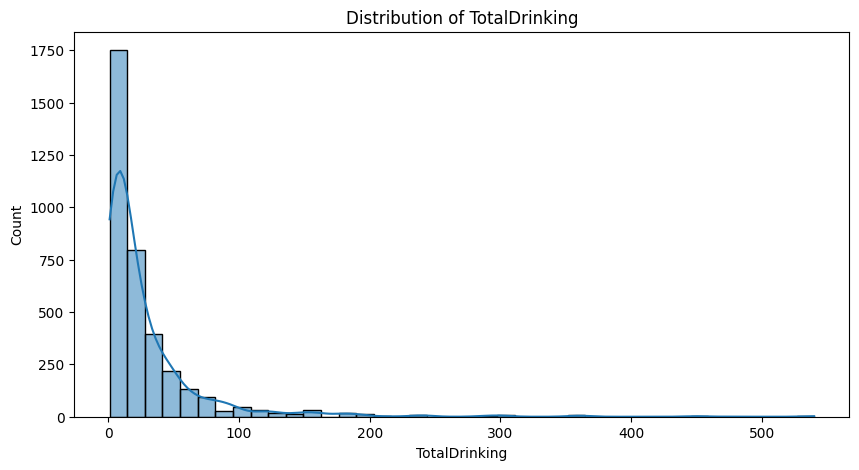

count    3629.000000
mean       28.768807
std        46.804985
min         1.000000
25%         5.000000
50%        16.000000
75%        32.000000
max       540.000000
Name: TotalDrinking, dtype: float64

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df1["TotalDrinking"], kde=True, bins=40)
plt.title("Distribution of TotalDrinking")
plt.show()

df["TotalDrinking"].describe()


In [4]:
cols=pd.read_csv('alcohol_features.csv')

In [5]:
cols = cols['features'].tolist()


In [15]:
df = df_filtered.copy()


In [5]:
df.head()

,Sex_Female,Age at First Drink,SexAttitudes_Index,SchoolSuspension_Z,Delinquency_Index,SchoolBehavior_Index,SchoolTrouble_Index,Age_FirstMarijuana,PeerSubstance_Index,InjuredSomeone,...,LiftWeights_W1,GroupFight,TroubleGetAlong_Students_W1,Trouble_HomeworkCompletion_W1,MotherEverSmoked,Rev_UpsetMother_Sex,HoursGames_W1,DrugsAvailable_Home,Support_Index,TotalDrinking
0,1,16.0,0.704868,-0.607756,0.284682,0.467625,1.75,0.0,2.666667,1.0,...,NaN,0.0,2.0,0.0,1.0,4.0,0.0,0.0,4.60,25.0
2,0,12.0,NaN,1.645398,0.624930,0.406031,1.75,13.0,1.333333,1.0,...,NaN,2.0,2.0,2.0,NaN,NaN,3.0,0.0,4.40,48.0
3,0,18.0,NaN,-0.607756,-0.167422,-0.159368,1.75,0.0,0.000000,0.0,...,NaN,0.0,3.0,2.0,NaN,NaN,2.0,0.0,4.60,72.0
4,0,22.0,0.415719,1.645398,-0.351844,0.210727,0.75,0.0,0.000000,0.0,...,NaN,0.0,0.0,1.0,NaN,4.0,4.0,0.0,4.20,2.0
6,1,16.0,NaN,-0.607756,-0.331527,-0.309846,1.00,0.0,0.000000,0.0,...,NaN,0.0,1.0,1.0,NaN,NaN,2.0,0.0,4.55,2.5


In [189]:
cols

['Age at First Drink',
 'Trouble Paying Attention',
 'LowReligiousImportance',
 'peer_alcohol_count',
 'Delinquency_Index',
 'FriendsRespect_Sex',
 'Rev_FeelGuilty_Sex',
 'Rev_UpsetMother_Sex',
 'Relax_Sex',
 'Attractive_Sex',
 'LessLonely_Sex',
 'GPA_Index',
 'ParentalWarmth_Index',
 'ParentalSupervision_Index',
 'SchoolCloseness',
 'SchoolSuspension',
 'Mother_Education',
 'Father_Education',
 'Household_Income',
 'Bills_Payment_Ability',
 'HomeDrugRisk_Index',
 'BuildingCondition',
 'StreetCondition',
 'SuicidalIdeation',
 'ReligionGroup_Buddhist',
 'ReligionGroup_Catholic',
 'ReligionGroup_Eastern Orthodox',
 'ReligionGroup_Hindu',
 'ReligionGroup_Jewish',
 'ReligionGroup_Muslim',
 'ReligionGroup_Other',
 'ReligionGroup_Protestant',
 'BuildingType_2',
 'BuildingType_3',
 'BuildingType_4',
 'BuildingType_5',
 'BuildingType_7',
 'NeighborhoodType_2',
 'NeighborhoodType_3',
 'NeighborhoodType_4',
 'NeighborhoodType_5',
 'NeighborhoodType_6',
 'Sex_Female',
 'BuildingType_6',
 'Buildin

In [16]:
df = df[df["TotalDrinking"].notna()].copy()


In [17]:
df["heavy_drinker"] = (df["TotalDrinking"] > 40).astype(int)


In [18]:
y = df["heavy_drinker"]

X = df.drop(columns=["TotalDrinking", "heavy_drinker"])


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [20]:
print("Train class counts:")
print(y_train.value_counts())

print("\nTest class counts:")
print(y_test.value_counts())


Train class counts:
heavy_drinker
0    2207
1     514
Name: count, dtype: int64

Test class counts:
heavy_drinker
0    736
1    172
Name: count, dtype: int64


## Modeling

## catboost

In [26]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
cat = CatBoostClassifier(
    iterations=600,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, 5],  # balance classes
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train)

y_prob_cat = cat.predict_proba(X_test)[:, 1]
y_pred_cat = (y_prob_cat >=0.3).astype(int)

print(confusion_matrix(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))
print("AUC:", roc_auc_score(y_test, y_prob_cat))


[[403 333]
 [ 45 127]]
              precision    recall  f1-score   support

           0       0.90      0.55      0.68       736
           1       0.28      0.74      0.40       172

    accuracy                           0.58       908
   macro avg       0.59      0.64      0.54       908
weighted avg       0.78      0.58      0.63       908

AUC: 0.6937800176946411


In [27]:
from sklearn.metrics import roc_curve
import numpy as np

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cat)

# Youden's J statistic
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold_cat = thresholds[best_idx]

print("Best threshold (Youden J):", round(best_threshold_cat, 4))


Best threshold (Youden J): 0.355


In [28]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

cat = CatBoostClassifier(
    iterations=600,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, 5],  # balance classes
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train)

y_prob_cat = cat.predict_proba(X_test)[:, 1]
y_pred_cat = (y_prob_cat >=best_threshold_cat).astype(int)

print(confusion_matrix(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))
print("AUC:", roc_auc_score(y_test, y_prob_cat))

[[464 272]
 [ 56 116]]
              precision    recall  f1-score   support

           0       0.89      0.63      0.74       736
           1       0.30      0.67      0.41       172

    accuracy                           0.64       908
   macro avg       0.60      0.65      0.58       908
weighted avg       0.78      0.64      0.68       908

AUC: 0.6937800176946411


In [ ]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

cat = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    class_weights=[1, 5]    # this helps imbalance
)

# parameter grid
param_grid = {
    'depth': [4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05],
    'iterations': [300, 500, 800],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0, 1, 5, 10],
}

cat.grid_search(param_grid, train_pool, verbose=False)


In [45]:
print("Best depth:", cat.get_param("depth"))
print("Best learning_rate:", cat.get_param("learning_rate"))
print("Best iterations:", cat.get_param("iterations"))
print("Best l2_leaf_reg:", cat.get_param("l2_leaf_reg"))
print("Best bagging_temperature:", cat.get_param("bagging_temperature"))



Best depth: 5
Best learning_rate: 0.05
Best iterations: 500
Best l2_leaf_reg: 9
Best bagging_temperature: 0


In [46]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

best_params = {
    'depth': 5,
    'iterations': 500,
    'learning_rate': 0.05,
    'l2_leaf_reg': 9,
    'bagging_temperature': 0,
    'class_weights': [1, 5],
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'random_seed': 42,
    'verbose': False
}

cat_final = CatBoostClassifier(**best_params)

cat_final.fit(X_train, y_train)

# Predictions
y_prob_final = cat_final.predict_proba(X_test)[:, 1]

# Optional: adjust threshold to improve recall
threshold = best_threshold
y_pred_final = (y_prob_final >= threshold).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))
print("AUC:", roc_auc_score(y_test, y_prob_final))


Confusion Matrix:
 [[473 263]
 [ 54 118]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.64      0.75       736
           1       0.31      0.69      0.43       172

    accuracy                           0.65       908
   macro avg       0.60      0.66      0.59       908
weighted avg       0.79      0.65      0.69       908

AUC: 0.6867100606673407


## Models

## XGBoost with tuning

In [29]:
X_train_xgb = X_train.copy()
X_test_xgb  = X_test.copy()


In [30]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve,
    classification_report, confusion_matrix
)
param_dist = {
    "n_estimators": randint(300, 900),
    "learning_rate": uniform(0.01, 0.1),
    "max_depth": randint(3, 9),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "gamma": uniform(0, 5)
}
xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1
)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_xgb, y_train)

print("Best CV AUC:", random_search.best_score_)
print("Best Parameters:")
print(random_search.best_params_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best CV AUC: 0.7279987166787079
Best Parameters:
{'colsample_bytree': np.float64(0.610167650697638), 'gamma': np.float64(0.5394571349665223), 'learning_rate': np.float64(0.013142918568673426), 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 395, 'subsample': np.float64(0.878206434570451)}


In [31]:
best_xgb = random_search.best_estimator_

best_xgb.fit(X_train_xgb, y_train)

y_prob = best_xgb.predict_proba(X_test_xgb)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("=======================================")
print(" XGBoost Test AUC:", round(auc, 4))
print("=======================================")


 XGBoost Test AUC: 0.7042


In [32]:
from sklearn.metrics import roc_curve
import numpy as np

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Youden's J statistic
youden_j = tpr - fpr

best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print("Best Threshold (Youden J):", round(best_threshold, 3))
print("Youden J:", round(youden_j[best_idx], 3))


Best Threshold (Youden J): 0.411
Youden J: 0.329


In [33]:
y_pred = (y_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, digits=3)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(cr)


Confusion Matrix:
[[413 323]
 [ 40 132]]

Classification Report:
              precision    recall  f1-score   support

           0      0.912     0.561     0.695       736
           1      0.290     0.767     0.421       172

    accuracy                          0.600       908
   macro avg      0.601     0.664     0.558       908
weighted avg      0.794     0.600     0.643       908



In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

performance_table = pd.DataFrame({
    "Metric": [
        "AUC",
        "Accuracy",
        "Precision (Class 1)",
        "Recall (Class 1)",
        "F1-score (Class 1)"
    ],
    "Value": [
        auc,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

performance_table


,Metric,Value
0,AUC,0.704152
1,Accuracy,0.600220
2,Precision (Class 1),0.290110
3,Recall (Class 1),0.767442
4,F1-score (Class 1),0.421053


In [35]:
booster = best_xgb.get_booster()
gain_dict = booster.get_score(importance_type="gain")

importance_df = (
    pd.DataFrame.from_dict(gain_dict, orient="index", columns=["Gain"])
    .reset_index()
    .rename(columns={"index": "Feature"})
    .sort_values("Gain", ascending=False)
)

importance_df["Gain_pct"] = importance_df["Gain"] / importance_df["Gain"].sum()

importance_df.head(20)


,Feature,Gain,Gain_pct
0,Sex_Female,85.716721,0.166424
1,Age at First Drink,27.670002,0.053723
7,Age_FirstMarijuana,25.248507,0.049021
3,SchoolSuspension_Z,24.920540,0.048385
20,Attractive_Sex,17.436028,0.033853
4,Delinquency_Index,16.529146,0.032092
5,SchoolBehavior_Index,16.422882,0.031886
17,EverTried_Cigarette_Z,15.815013,0.030706
2,SexAttitudes_Index,15.470266,0.030036
22,LowReligiosityIndex_W1,14.929893,0.028987


X_bg_np dtype: float32
X_test_np dtype: float32


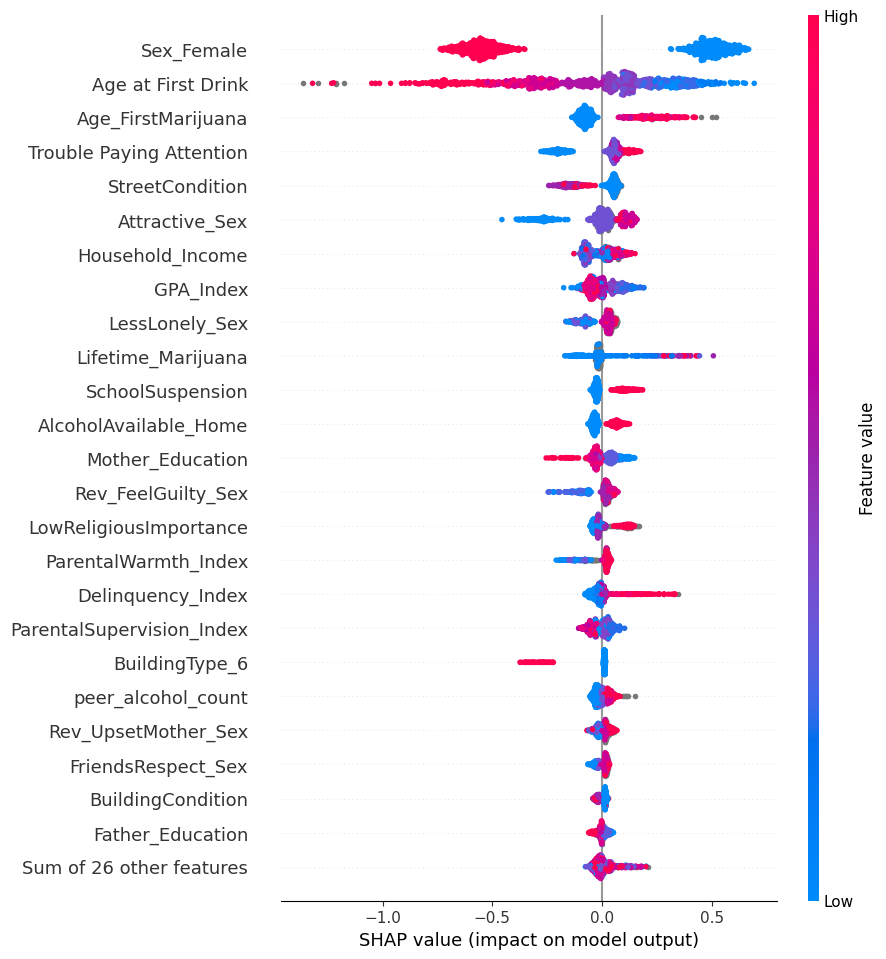

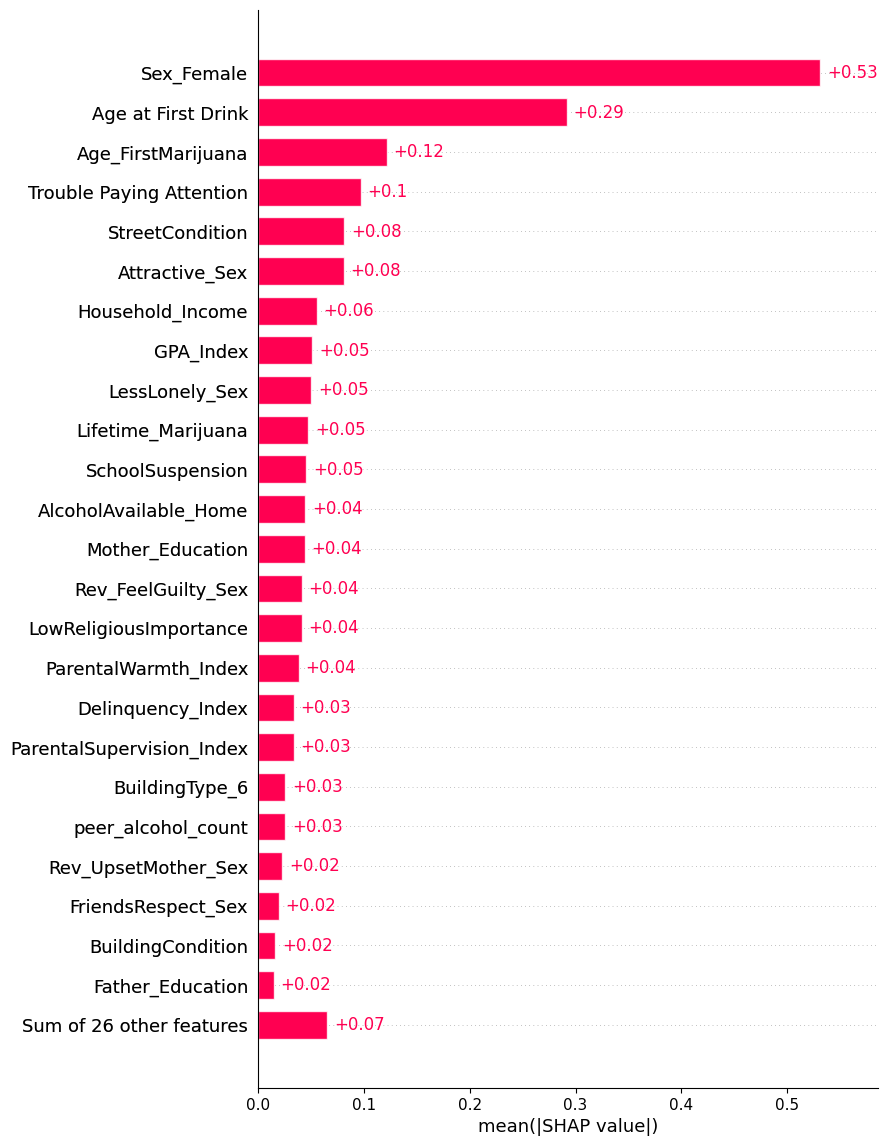

Top SHAP features: ['Sex_Female', 'Age at First Drink', 'Age_FirstMarijuana', 'Trouble Paying Attention', 'StreetCondition', 'Attractive_Sex', 'Household_Income', 'GPA_Index', 'LessLonely_Sex', 'Lifetime_Marijuana']


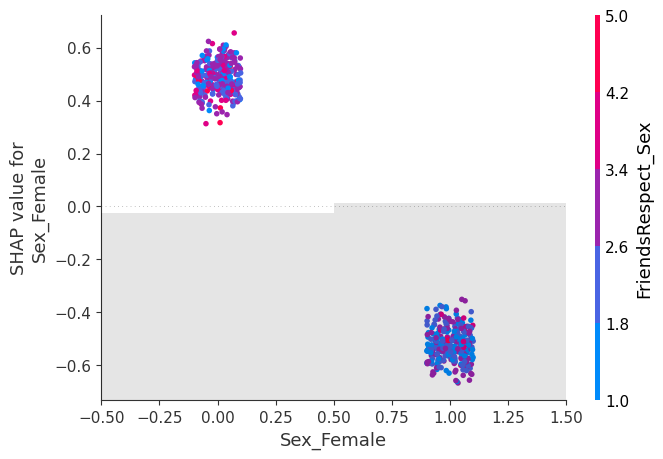

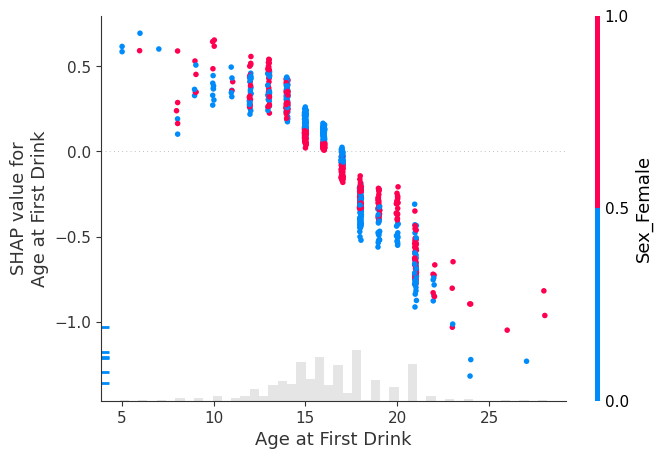

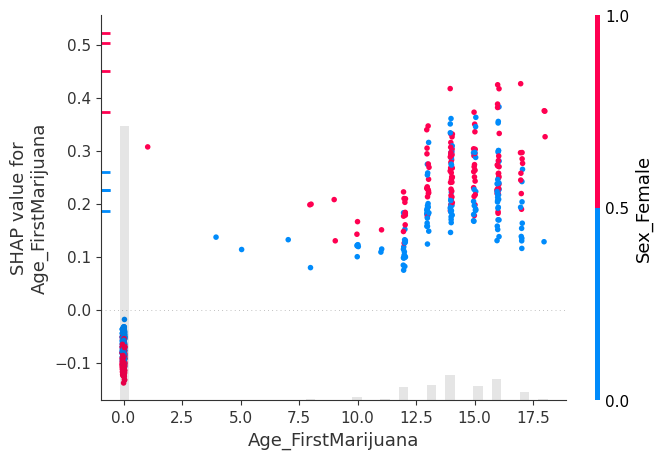

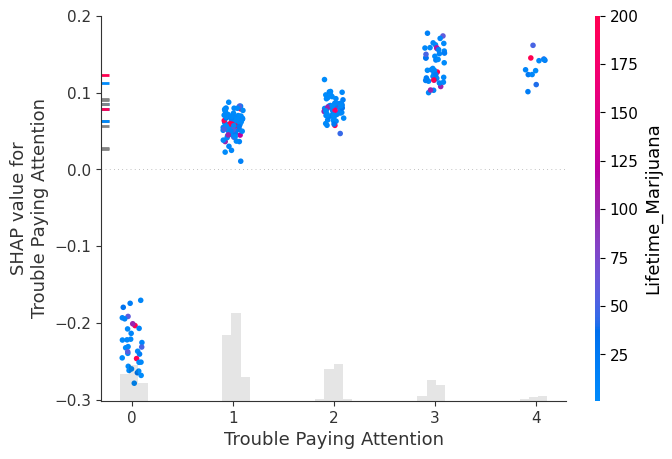

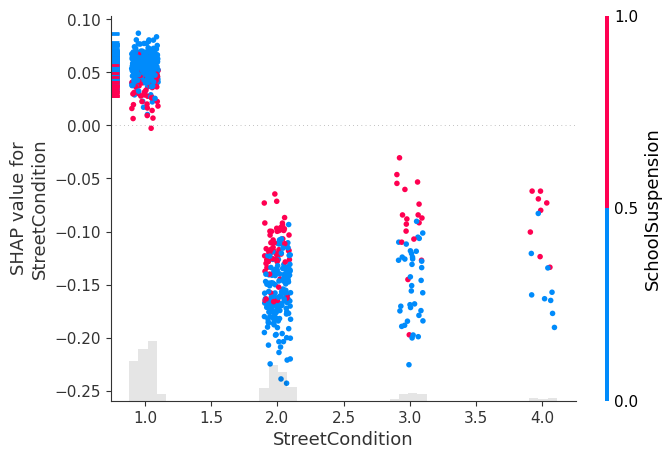

Explaining test row index: 681


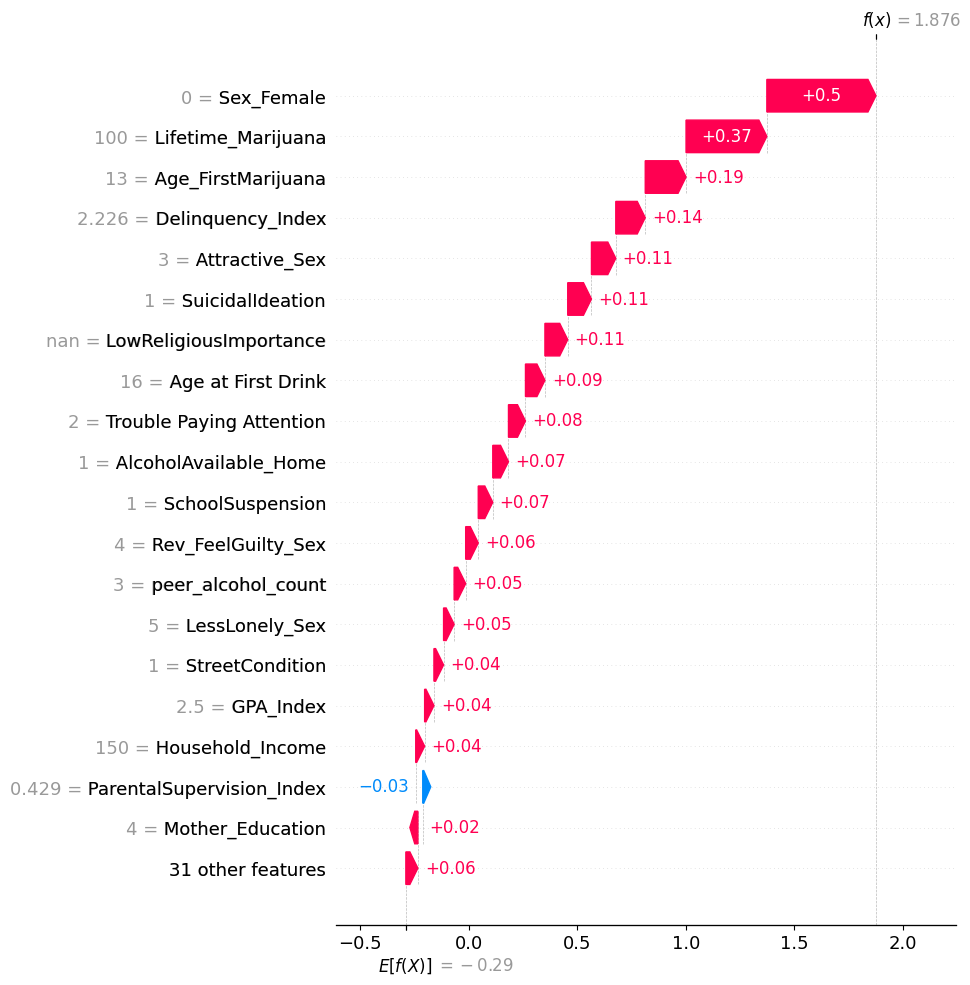

In [55]:
# ============================
# SHAP analysis for best_xgb
# ============================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Make sure X_* are DataFrames (keeps feature names for plots)
if not isinstance(X_train_xgb, pd.DataFrame):
    X_train_xgb = pd.DataFrame(X_train_xgb)
if not isinstance(X_test_xgb, pd.DataFrame):
    X_test_xgb = pd.DataFrame(X_test_xgb)

# (Optional but recommended) background sample for speed/stability
bg_size = min(500, len(X_train_xgb))
X_bg = X_train_xgb.sample(bg_size, random_state=42)


import numpy as np
import shap

feature_names = X_train_xgb.columns.tolist()

# 1) Convert bool -> int, then force everything to float32
def force_float32(df):
    df = df.copy()
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(np.int8)
    return df.astype(np.float32)

X_train_shap = force_float32(X_train_xgb)
X_test_shap  = force_float32(X_test_xgb)

# 2) Background sample
bg_size = min(200, len(X_train_shap))
X_bg = X_train_shap.sample(bg_size, random_state=42)

# 3) Convert to numpy float32 (NOW it won't be object)
X_bg_np   = X_bg.to_numpy(dtype=np.float32)
X_test_np = X_test_shap.to_numpy(dtype=np.float32)

print("X_bg_np dtype:", X_bg_np.dtype)
print("X_test_np dtype:", X_test_np.dtype)

# 4) SHAP
explainer = shap.Explainer(best_xgb, X_bg_np, feature_names=feature_names)
shap_values = explainer(X_test_np)

shap.plots.beeswarm(shap_values, max_display=25)




# (Alternative global view: mean(|SHAP|) bar)
shap.plots.bar(shap_values, max_display=25)

# ---------------------------------------------------------
# B) DEPENDENCE: top features (scatter plots)
# ---------------------------------------------------------
# Get top features by mean absolute SHAP
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]
top_features = X_test_xgb.columns[top_idx].tolist()

print("Top SHAP features:", top_features)

# Dependence plots for top features
for feat in top_features[:5]:
    shap.plots.scatter(shap_values[:, feat], color=shap_values)

# ---------------------------------------------------------
# C) LOCAL: explain a single prediction
# ---------------------------------------------------------
# Choose an instance index (e.g., highest predicted risk)
idx = int(np.argmax(best_xgb.predict_proba(X_test_xgb)[:, 1]))
print("Explaining test row index:", idx)

# Waterfall plot for that instance
shap.plots.waterfall(shap_values[idx], max_display=20)

# Force plot (interactive in notebooks; may need JS init)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values.values[idx, :],
    X_test_xgb.iloc[idx, :],
)

# ---------------------------------------------------------
# D) (Optional) SHAP values table export
# ---------------------------------------------------------
shap_df = pd.DataFrame(shap_values.values, columns=X_test_xgb.columns)
shap_df["pred_prob"] = best_xgb.predict_proba(X_test_xgb)[:, 1]
shap_df["y_true"] = np.array(y_test)

# Save if you want
# shap_df.to_csv("shap_values_test.csv", index=False)


In [88]:
# SHAP values array: (n_samples, n_features)
S = shap_values.values

# Optional but recommended: standardize
from sklearn.preprocessing import StandardScaler
S_scaled = StandardScaler().fit_transform(S)


In [89]:
from sklearn.cluster import KMeans

k = 3  # start here
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
archetypes = kmeans.fit_predict(S_scaled)


In [90]:
df_archetypes = X_test_xgb.copy()
df_archetypes["archetype"] = archetypes
df_archetypes["pred_prob"] = best_xgb.predict_proba(X_test_xgb)[:, 1]


In [91]:
import pandas as pd
import numpy as np

archetype_profiles = (
    pd.DataFrame(S, columns=feature_names)
      .assign(archetype=archetypes)
      .groupby("archetype")
      .mean()
)

archetype_profiles


,Age at First Drink,Trouble Paying Attention,LowReligiousImportance,peer_alcohol_count,Delinquency_Index,FriendsRespect_Sex,Rev_FeelGuilty_Sex,Rev_UpsetMother_Sex,Relax_Sex,Attractive_Sex,...,NeighborhoodType_6,Sex_Female,BuildingType_6,BuildingType_8,Age_FirstMarijuana,Lifetime_Marijuana,Age_FirstCocaine,AlcoholAvailable_Home,DrugsAvailable_Home,GunAvailable_Home
archetype,,,,,,,,,,,,,,,,,,,,,
0,-0.085730,0.011360,-0.005738,-0.010715,-0.013444,0.016162,0.014363,0.016486,-0.004973,0.031037,...,0.0,-0.025308,-0.005391,0.0,-0.044110,-0.022165,-0.000047,-0.004785,0.000041,0.000119
1,0.023812,0.036361,0.035280,0.027817,0.050047,0.004884,0.021341,0.005521,0.004110,0.036361,...,0.0,0.067229,0.001200,0.0,0.143477,0.051360,0.000379,0.000777,0.000008,0.000284
2,-0.087358,-0.003274,0.000927,-0.002103,-0.016644,-0.019704,-0.043023,-0.015766,0.001553,-0.075701,...,0.0,-0.139023,-0.004286,0.0,-0.013143,-0.028406,0.000046,-0.000230,-0.000013,0.000103



Archetype 0


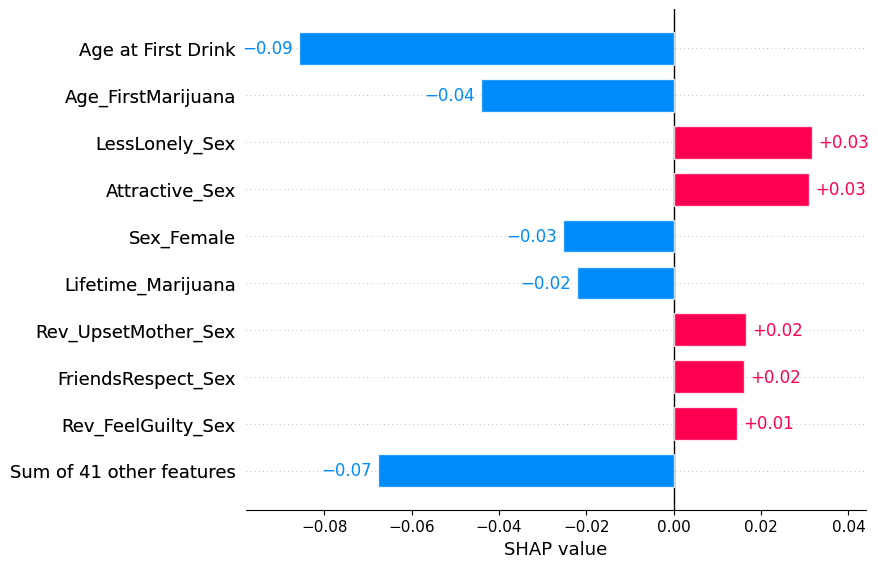


Archetype 1


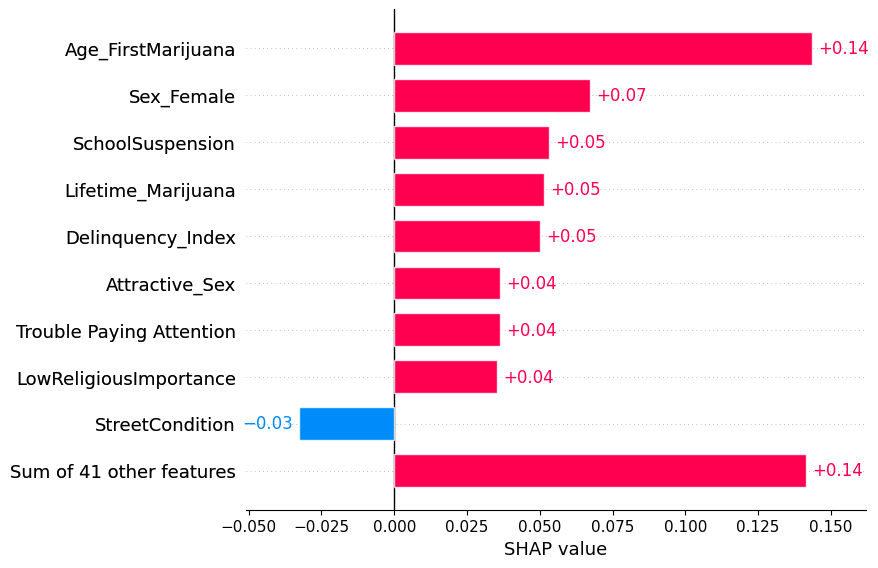


Archetype 2


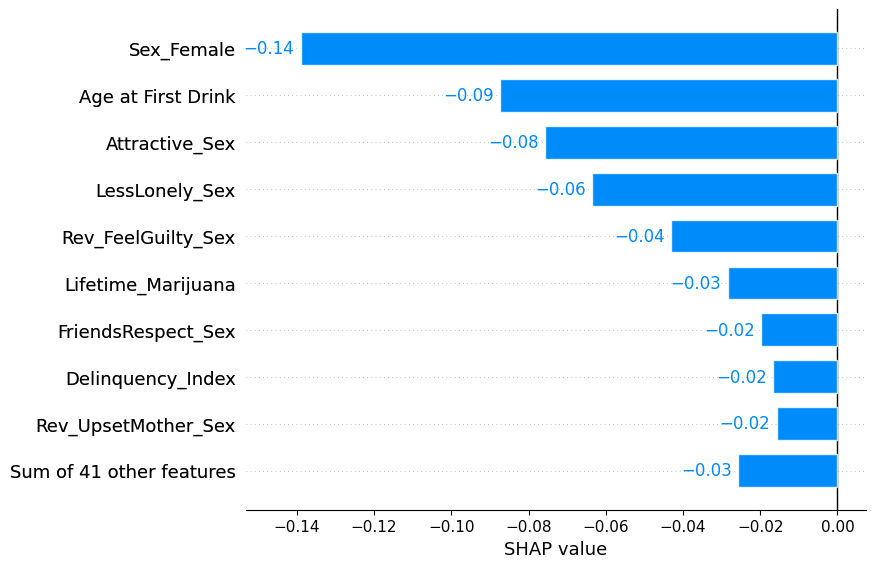

In [92]:
for a in sorted(df_archetypes["archetype"].unique()):
    print(f"\nArchetype {a}")
    shap.plots.bar(
        shap.Explanation(
            values=archetype_profiles.loc[a].values,
            feature_names=feature_names
        ),
        max_display=10
    )


In [93]:
df_archetypes.groupby("archetype")["pred_prob"].describe()


,count,mean,std,min,25%,50%,75%,max
archetype,,,,,,,,
0,427.0,0.411679,0.190117,0.063423,0.253392,0.382509,0.593280,0.773305
1,217.0,0.565810,0.172946,0.147708,0.429046,0.583567,0.716347,0.867170
2,264.0,0.327317,0.149336,0.084732,0.200301,0.295231,0.432628,0.656586


## Logistic (L2)

In [36]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score

# Your existing train/test split
X_train2 = X_train.copy()
X_test2  = X_test.copy()





# ============================================================
# 2) PLAIN LOGISTIC REGRESSION (L2), CLASS-WEIGHTED
# ============================================================

pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",    # <<< HANDLE 1:5 IMBALANCE
        max_iter=3000
    ))
])

pipe_lr.fit(X_train2, y_train)

y_pred = pipe_lr.predict_proba(X_test2)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print("=======================================")
print(" LOGISTIC REGRESSION (balanced) AUC:", auc)
print("=======================================")


# ============================================================
# 3) COEFFICIENTS (INTERPRETABLE OUTPUT)
# ============================================================

coef = pipe_lr.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (stronger risk):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective):")
print(coef_df.tail(15))

 LOGISTIC REGRESSION (balanced) AUC: 0.7069167087967645

Top positive coefficients (stronger risk):
                         feature      coef
4              Delinquency_Index  0.197227
3             SchoolSuspension_Z  0.139999
7             Age_FirstMarijuana  0.138121
20                Attractive_Sex  0.135099
18      Trouble Paying Attention  0.104078
21              ExpectCollege_W1  0.102090
22        LowReligiosityIndex_W1  0.101257
17         EverTried_Cigarette_Z  0.099651
6            SchoolTrouble_Index  0.084066
2             SexAttitudes_Index  0.034842
14                   Relax_Sex_Z  0.031947
13            Rev_FeelGuilty_Sex  0.022138
12                     GPA_Index  0.020754
24  Trouble_GetAlong_Teachers_W1  0.003803
9                 InjuredSomeone  0.001264

Top negative coefficients (protective):
                    feature      coef
10           LessLonely_Sex -0.011749
28  DrinkFrequency_Past12mo -0.021816
15              SoldDrugs_Z -0.025510
11       FriendsRes

========== METRICS ==========
AUC              : 0.7069167087967645
Accuracy         : 0.6079295154185022
Precision        : 0.28703703703703703
Recall           : 0.7209302325581395
F1 Score         : 0.4105960264900662

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.58      0.71       736
           1       0.29      0.72      0.41       172

    accuracy                           0.61       908
   macro avg       0.59      0.65      0.56       908
weighted avg       0.78      0.61      0.65       908



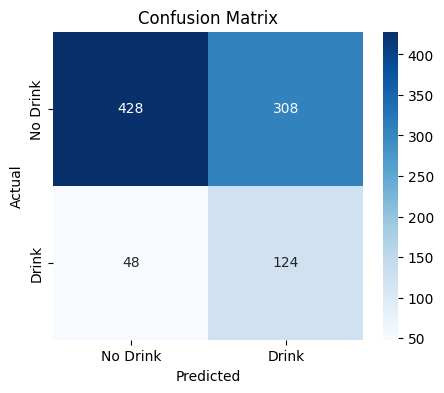

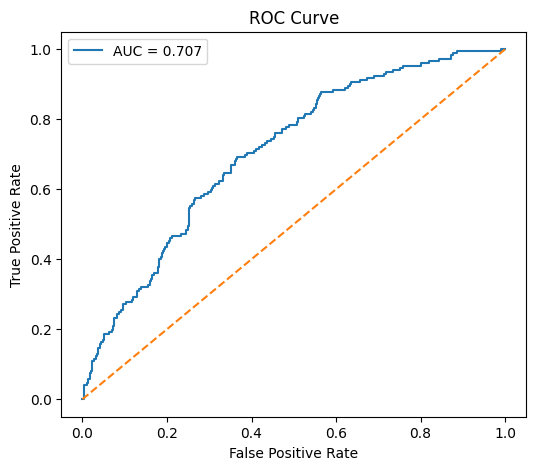

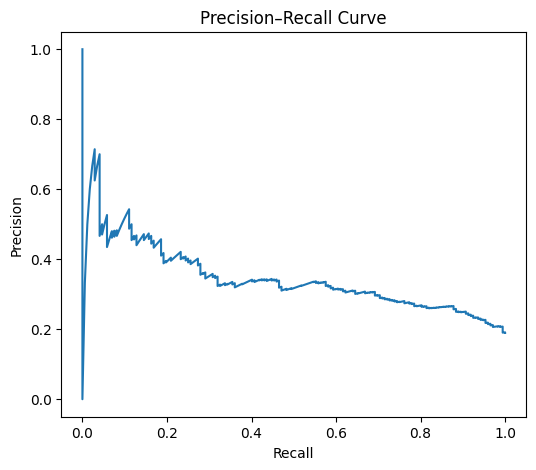

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1) Predictions
# ============================================================

y_pred_proba = pipe_lr.predict_proba(X_test2)[:, 1]
y_pred_class = (y_pred_proba >= 0.4522).astype(int)

# ============================================================
# 2) Core Metrics
# ============================================================

auc = roc_auc_score(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred_class)
prec = precision_score(y_test, y_pred_class)
rec = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

print("========== METRICS ==========")
print("AUC              :", auc)
print("Accuracy         :", acc)
print("Precision        :", prec)
print("Recall           :", rec)
print("F1 Score         :", f1)
print("===================================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

# ============================================================
# 3) Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Drink", "Drink"],
            yticklabels=["No Drink", "Drink"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================================
# 4) ROC Curve
# ============================================================

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================
# 5) Precision–Recall Curve
# ============================================================

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


## ElasticNet

In [23]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd




# ============================================
# 2) ELASTIC NET LOGISTIC REGRESSION
# ============================================

pipe_en = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=20,                        # number of C values to test
        cv=5,                         # 5-fold CV
        penalty="elasticnet",
        solver="saga",                # ONLY solver that supports elasticnet
        l1_ratios=[0.1,0.3,0.5,0.7,0.9],
        scoring="roc_auc",            # optimize for AUC
        class_weight="balanced",      # fix imbalance
        max_iter=5000,
        n_jobs=-1
    ))
])

pipe_en.fit(X_train2, y_train)

# ============================================
# 3) Evaluate AUC
# ============================================
y_pred = pipe_en.predict_proba(X_test2)[:, 1]
auc = roc_auc_score(y_test, y_pred)

print("=======================================")
print(" Elastic Net Logistic Regression AUC:", auc)
print("=======================================")


# ============================================
# 4) Coefficients
# ============================================
coef = pipe_en.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (risk factors):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective factors):")
print(coef_df.tail(15))


 Elastic Net Logistic Regression AUC: 0.7100527679474217

Top positive coefficients (risk factors):
                     feature      coef
7         Age_FirstMarijuana  0.097256
20            Attractive_Sex  0.090630
22    LowReligiosityIndex_W1  0.084570
18  Trouble Paying Attention  0.075596
3         SchoolSuspension_Z  0.071112
17     EverTried_Cigarette_Z  0.062659
4          Delinquency_Index  0.051997
6        SchoolTrouble_Index  0.050867
13        Rev_FeelGuilty_Sex  0.011378
9             InjuredSomeone  0.000000
8        PeerSubstance_Index  0.000000
10            LessLonely_Sex  0.000000
11        FriendsRespect_Sex  0.000000
2         SexAttitudes_Index  0.000000
5       SchoolBehavior_Index  0.000000

Top negative coefficients (protective factors):
                         feature      coef
30                     Jumped_W1  0.000000
14                   Relax_Sex_Z  0.000000
12                     GPA_Index  0.000000
19              PhysicalFight_W1  0.000000
15          

In [38]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import numpy as np

# ============================================
# 1) Predicted probabilities
# ============================================
y_prob = pipe_en.predict_proba(X_test2)[:, 1]

# ============================================
# 2) AUC metrics
# ============================================
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)


from sklearn.metrics import roc_curve
import numpy as np
import pandas as pd

# ============================================
# 3) Threshold optimization (Youden's J)
# ============================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)

best_threshold = thresholds[best_idx]

metrics_df = pd.DataFrame({
    "threshold": thresholds,
    "tpr_recall": tpr,
    "fpr": fpr,
    "specificity": 1 - fpr,
    "youden_j": youden_j
})

print("Best Threshold (Youden J):", round(best_threshold, 3))
print("Best Youden J:", round(youden_j[best_idx], 3))


# ============================================
# 4) Final predictions at best threshold
# ============================================
y_pred_best = (y_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
report = classification_report(y_test, y_pred_best, output_dict=True)

# ============================================
# 5) Display results
# ============================================

print("=======================================")
print("ELASTIC NET LOGISTIC REGRESSION – FULL PERFORMANCE")
print("=======================================\n")

print(f"ROC–AUC: {roc_auc:.4f}")
print(f"PR–AUC : {pr_auc:.4f}")
print(f"Best Threshold: {best_threshold:.3f}\n")

print("Confusion Matrix (at best threshold):")
print(cm, "\n")

print("Classification Report (at best threshold):")
print(pd.DataFrame(report).T, "\n")



# ============================================
# 6) Compact performance table (presentation-ready)
# ============================================
performance_summary = pd.DataFrame({
    "Metric": [
        "ROC–AUC",
        "PR–AUC",
        "Accuracy",
        "Precision (Class 1)",
        "Recall (Class 1)",
        "F1-score (Class 1)"
    ],
    "Value": [
        roc_auc,
        pr_auc,
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best, zero_division=0),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best)
    ]
}).round(3)

print("\nFinal Performance Summary:")
print(performance_summary)


Best Threshold (Youden J): 0.495
Best Youden J: 0.337
ELASTIC NET LOGISTIC REGRESSION – FULL PERFORMANCE

ROC–AUC: 0.7101
PR–AUC : 0.3590
Best Threshold: 0.495

Confusion Matrix (at best threshold):
[[479 257]
 [ 54 118]] 

Classification Report (at best threshold):
              precision    recall  f1-score     support
0              0.898687  0.650815  0.754925  736.000000
1              0.314667  0.686047  0.431444  172.000000
accuracy       0.657489  0.657489  0.657489    0.657489
macro avg      0.606677  0.668431  0.593185  908.000000
weighted avg   0.788057  0.657489  0.693649  908.000000 


Final Performance Summary:
                Metric  Value
0              ROC–AUC  0.710
1               PR–AUC  0.359
2             Accuracy  0.657
3  Precision (Class 1)  0.315
4     Recall (Class 1)  0.686
5   F1-score (Class 1)  0.431


In [39]:
import numpy as np
import pandas as pd

# Extract coefficients
lr_en = pipe_en.named_steps["lr"]
coefs = lr_en.coef_[0]

coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coefs,
    "abs_coef": np.abs(coefs)
}).sort_values("abs_coef", ascending=False)

# Inspect
coef_df.head(10)


,feature,coef,abs_coef
0,Sex_Female,-0.504910,0.504910
1,Age at First Drink,-0.347698,0.347698
7,Age_FirstMarijuana,0.097256,0.097256
20,Attractive_Sex,0.090630,0.090630
22,LowReligiosityIndex_W1,0.084570,0.084570
18,Trouble Paying Attention,0.075596,0.075596
3,SchoolSuspension_Z,0.071112,0.071112
17,EverTried_Cigarette_Z,0.062659,0.062659
26,FriendCare_W1,-0.054429,0.054429
4,Delinquency_Index,0.051997,0.051997


In [40]:
import numpy as np
import pandas as pd

# ============================================
# 1) Extract fitted Elastic Net model
# ============================================
lr_en = pipe_en.named_steps["lr"]

# Best hyperparameters
best_C = lr_en.C_[0]
best_l1 = lr_en.l1_ratio_[0]

print(f"Selected C: {best_C}")
print(f"Selected l1_ratio: {best_l1}")

# ============================================
# 2) Build FULL coefficient table
# ============================================
coef = lr_en.coef_[0]

en_table = pd.DataFrame({
    "Feature": X_train2.columns,
    "Coefficient": coef,
})

# Odds ratios
en_table["Odds_Ratio"] = np.exp(en_table["Coefficient"])

# Absolute magnitude (importance)
en_table["Abs_Coefficient"] = en_table["Coefficient"].abs()

# Direction
en_table["Direction"] = np.where(
    en_table["Coefficient"] > 0, "Risk-increasing", "Protective"
)

# Feature selection indicator
en_table["Selected"] = en_table["Coefficient"] != 0

# Rank by importance
en_table = en_table.sort_values("Abs_Coefficient", ascending=False)
en_table["Rank"] = range(1, len(en_table) + 1)

# ============================================
# 3) Separate retained vs dropped features
# ============================================
en_selected = en_table[en_table["Selected"]].copy()
en_dropped  = en_table[~en_table["Selected"]].copy()

print("\nNumber of retained features:", en_selected.shape[0])
print("Number of shrunk-to-zero features:", en_dropped.shape[0])

# ============================================
# 4) Display top effects
# ============================================
print("\nTop 15 risk-increasing predictors:")
print(
    en_selected[en_selected["Coefficient"] > 0]
    .head(15)[["Rank","Feature","Coefficient","Odds_Ratio"]]
)

print("\nTop 15 protective predictors:")
print(
    en_selected[en_selected["Coefficient"] < 0]
    .head(15)[["Rank","Feature","Coefficient","Odds_Ratio"]]
)



Selected C: 0.012742749857031334
Selected l1_ratio: 0.3

Number of retained features: 16
Number of shrunk-to-zero features: 15

Top 15 risk-increasing predictors:
    Rank                   Feature  Coefficient  Odds_Ratio
7      3        Age_FirstMarijuana     0.097256    1.102142
20     4            Attractive_Sex     0.090630    1.094864
22     5    LowReligiosityIndex_W1     0.084570    1.088249
18     6  Trouble Paying Attention     0.075596    1.078526
3      7        SchoolSuspension_Z     0.071112    1.073701
17     8     EverTried_Cigarette_Z     0.062659    1.064663
4     10         Delinquency_Index     0.051997    1.053373
6     11       SchoolTrouble_Index     0.050867    1.052183
13    16        Rev_FeelGuilty_Sex     0.011378    1.011443

Top 15 protective predictors:
    Rank              Feature  Coefficient  Odds_Ratio
0      1           Sex_Female    -0.504910    0.603560
1      2   Age at First Drink    -0.347698    0.706312
26     9        FriendCare_W1    -0.05442

## Plain Logistic Regression

In [41]:
selected_features = en_selected["Feature"].tolist()

print("Number of Elastic Net–selected features:", len(selected_features))


Number of Elastic Net–selected features: 16


In [42]:
X_train_en_selected = X_train2[selected_features].copy()
X_test_en_selected  = X_test2[selected_features].copy()



In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_en_selected),
    columns=X_train_en_selected.columns,
    index=X_train_en_selected.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_en_selected),
    columns=X_test_en_selected.columns,
    index=X_test_en_selected.index
)


In [44]:
X_train_imp = X_train_imp.astype(float)
X_test_imp  = X_test_imp.astype(float)


In [45]:
import statsmodels.api as sm


X_test_sm  = sm.add_constant(X_test_imp,  has_constant="add")


In [46]:
X_train_sm = sm.add_constant(X_train_imp, has_constant="add")
logit_model = sm.Logit(y_train, X_train_sm)

logit_result = logit_model.fit(
    method="newton",
    maxiter=3000,
    disp=True
)


Optimization terminated successfully.
         Current function value: 0.424022
         Iterations 6


In [47]:
logit_result.prsquared


np.float64(0.12505255883842303)

In [48]:
logit_result.llr, logit_result.llr_pvalue


(np.float64(329.8052317234042), np.float64(1.6618202533657254e-60))

In [49]:
# Coefficients
params = logit_result.params
se = logit_result.bse
z_stats = params / se
p_values = logit_result.pvalues

# Confidence intervals (log-odds)
conf = logit_result.conf_int()
conf.columns = ["CI 2.5%", "CI 97.5%"]

# Odds ratios + CI
odds_ratios = np.exp(params)
conf_odds = np.exp(conf)


In [50]:
logit_table = pd.DataFrame({
    "Variable": params.index,
    "Coefficient (β)": params.values,
    "Std. Error": se.values,
    "z-stat": z_stats.values,
    "p-value": p_values.values,
    "Odds Ratio": odds_ratios.values,
    "OR CI 2.5%": conf_odds["CI 2.5%"].values,
    "OR CI 97.5%": conf_odds["CI 97.5%"].values
})

# Drop intercept row for presentation
logit_table = logit_table[logit_table["Variable"] != "const"]

# Sort by absolute effect size
logit_table["abs_beta"] = np.abs(logit_table["Coefficient (β)"])
logit_table = logit_table.sort_values("abs_beta", ascending=False)

logit_table = logit_table.drop(columns="abs_beta")

logit_table


,Variable,Coefficient (β),Std. Error,z-stat,p-value,Odds Ratio,OR CI 2.5%,OR CI 97.5%
1,Sex_Female,-1.200617,0.120096,-9.997132,1.568748e-23,0.301009,0.237877,0.380895
10,Delinquency_Index,0.207231,0.116721,1.775439,7.582542e-02,1.230267,0.978692,1.546510
12,HighEduExpectations,-0.184451,0.223109,-0.826730,4.083903e-01,0.831561,0.537011,1.287671
15,Pleasure_Sex,-0.177639,0.071587,-2.481444,1.308512e-02,0.837245,0.727642,0.963357
9,FriendCare_W1,-0.160979,0.071630,-2.247357,2.461722e-02,0.851310,0.739802,0.979624
14,Fight_Serious_Z,-0.158671,0.069963,-2.267921,2.333402e-02,0.853277,0.743939,0.978685
4,Attractive_Sex,0.157237,0.072461,2.169946,3.001091e-02,1.170273,1.015332,1.348858
6,Trouble Paying Attention,0.132591,0.082272,1.611614,1.070459e-01,1.141783,0.971747,1.341571
5,LowReligiosityIndex_W1,0.131510,0.064329,2.044343,4.091964e-02,1.140549,1.005443,1.293811
2,Age at First Drink,-0.125050,0.018488,-6.763811,1.344087e-11,0.882453,0.851049,0.915016


In [51]:
selected_features = X_train_en_selected.columns.tolist()


In [52]:
X_test_en_selected = X_test.reindex(
    columns=selected_features,
    fill_value=0
)


In [53]:
assert list(X_train_en_selected.columns) == list(X_test_en_selected.columns)


In [54]:
X_test_imp  = X_test_imp.astype(float)

In [55]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Predicted probabilities
y_prob_test = logit_result.predict(X_test_sm)

auc = roc_auc_score(y_test, y_prob_test)
print("Plain logistic AUC:", auc)

# Choose threshold (example: 0.5)
y_pred_test = (y_prob_test >= 0.22).astype(int)

print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))


Plain logistic AUC: 0.7096656976744186
[[536 200]
 [ 74  98]]
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       736
           1       0.33      0.57      0.42       172

    accuracy                           0.70       908
   macro avg       0.60      0.65      0.61       908
weighted avg       0.77      0.70      0.72       908



In [56]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, confusion_matrix, classification_report

# ============================================
# 1) ROC curve
# ============================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

# ============================================
# 2) Youden's J
# ============================================
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

# ============================================
# 3) Summary table (optional but nice)
# ============================================
youden_df = pd.DataFrame({
    "threshold": thresholds,
    "tpr_recall": tpr,
    "fpr": fpr,
    "specificity": 1 - fpr,
    "youden_j": youden_j
}).sort_values("youden_j", ascending=False)

print("Best Threshold (Youden):", round(best_threshold, 3))
print("Best Youden J:", round(youden_j[best_idx], 3))


Best Threshold (Youden): 0.132
Best Youden J: 0.324


In [57]:
y_pred_best = (y_prob_test >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Confusion Matrix:
[[367 369]
 [ 30 142]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.50      0.65       736
           1       0.28      0.83      0.42       172

    accuracy                           0.56       908
   macro avg       0.60      0.66      0.53       908
weighted avg       0.80      0.56      0.60       908



## Random Forest

Best Threshold (Youden): 0.18
Best Youden J: 0.282

RANDOM FOREST — FULL PERFORMANCE (YOUDEN)

ROC–AUC: 0.6779
PR–AUC : 0.3018
Best Threshold (Youden): 0.180

Confusion Matrix (at Youden threshold):
[[409 327]
 [ 47 125]] 

Classification Report (at Youden threshold):
              precision    recall  f1-score     support
0              0.896930  0.555707  0.686242  736.000000
1              0.276549  0.726744  0.400641  172.000000
accuracy       0.588106  0.588106  0.588106    0.588106
macro avg      0.586739  0.641225  0.543441  908.000000
weighted avg   0.779413  0.588106  0.632141  908.000000 

Final Performance Summary:
                Metric   Value
0              ROC–AUC  0.6779
1               PR–AUC  0.3018
2             Accuracy  0.5881
3  Precision (Class 1)  0.2765
4     Recall (Class 1)  0.7267
5   F1-score (Class 1)  0.4006
6     Youden Threshold  0.1800
7             Youden J  0.2825


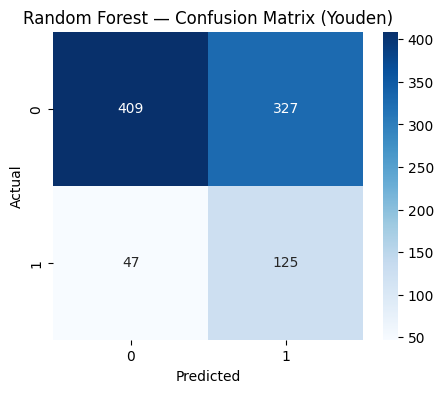

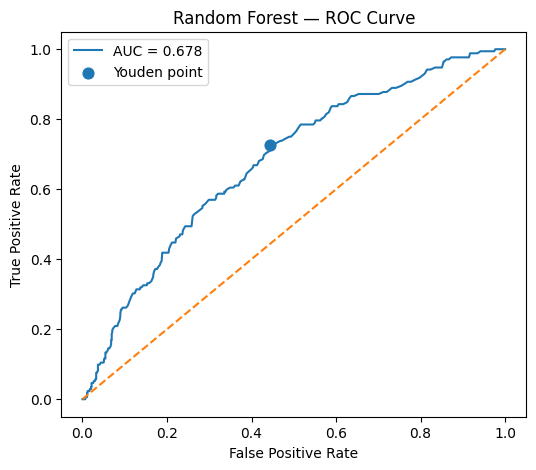

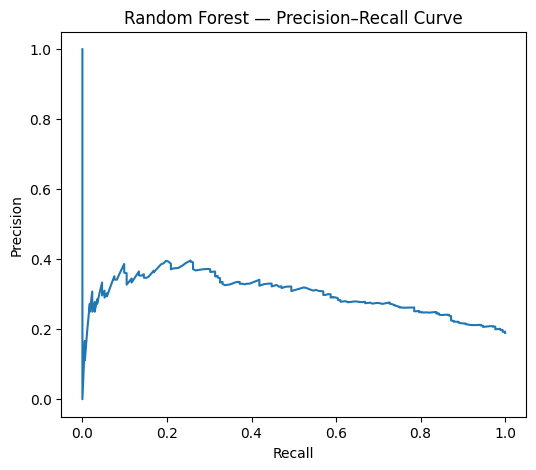

In [58]:
# ============================================================
# RANDOM FOREST + YOUDEN THRESHOLD (FULL CODE)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1) Train Random Forest
# ============================================================

pipe_rf = Pipeline([
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=None,      # try "balanced" if needed
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train, y_train)

# ============================================================
# 2) Predicted probabilities
# ============================================================

y_prob = pipe_rf.predict_proba(X_test)[:, 1]

# ============================================================
# 3) Youden threshold (from ROC curve)
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print("Best Threshold (Youden):", round(best_threshold, 3))
print("Best Youden J:", round(youden_j[best_idx], 3))

# Optional: table for inspection
youden_df = pd.DataFrame({
    "threshold": thresholds,
    "tpr_recall": tpr,
    "fpr": fpr,
    "specificity": 1 - fpr,
    "youden_j": youden_j
}).sort_values("youden_j", ascending=False)

# ============================================================
# 4) Final predictions using Youden threshold
# ============================================================

y_pred = (y_prob >= best_threshold).astype(int)

# ============================================================
# 5) Metrics
# ============================================================

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("\n=======================================")
print("RANDOM FOREST — FULL PERFORMANCE (YOUDEN)")
print("=======================================\n")
print(f"ROC–AUC: {roc_auc:.4f}")
print(f"PR–AUC : {pr_auc:.4f}")
print(f"Best Threshold (Youden): {best_threshold:.3f}\n")

print("Confusion Matrix (at Youden threshold):")
cm = confusion_matrix(y_test, y_pred)
print(cm, "\n")

print("Classification Report (at Youden threshold):")
print(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T, "\n")

performance_summary = pd.DataFrame({
    "Metric": [
        "ROC–AUC",
        "PR–AUC",
        "Accuracy",
        "Precision (Class 1)",
        "Recall (Class 1)",
        "F1-score (Class 1)",
        "Youden Threshold",
        "Youden J"
    ],
    "Value": [
        roc_auc,
        pr_auc,
        acc,
        prec,
        rec,
        f1,
        best_threshold,
        youden_j[best_idx]
    ]
}).round(4)

print("Final Performance Summary:")
print(performance_summary)

# ============================================================
# 6) Confusion Matrix Plot
# ============================================================

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.title("Random Forest — Confusion Matrix (Youden)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================================
# 7) ROC Curve Plot
# ============================================================

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.scatter(fpr[best_idx], tpr[best_idx], marker="o", s=60, label="Youden point")
plt.title("Random Forest — ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================================
# 8) Precision–Recall Curve Plot
# ============================================================

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.title("Random Forest — Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()
